In [26]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib as plt

from datasets import load_dataset

# load dataset

using hugging face dataset and importing it using load_dataset


In [27]:
emotion_dataset = load_dataset("dair-ai/emotion")
emotion_dataset

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 16000
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
})

In [28]:
emotion_dataset["train"]

Dataset({
    features: ['text', 'label'],
    num_rows: 16000
})

In [29]:
# load emotion text n label seperate n sore it in variable
train_text = emotion_dataset["train"]["text"]
train_label = emotion_dataset["train"]["label"]
test_text = emotion_dataset["test"]["text"]
test_label = emotion_dataset["test"]["label"]

In [30]:
print(train_text)
print(train_label)

Column(['i didnt feel humiliated', 'i can go from feeling so hopeless to so damned hopeful just from being around someone who cares and is awake', 'im grabbing a minute to post i feel greedy wrong', 'i am ever feeling nostalgic about the fireplace i will know that it is still on the property', 'i am feeling grouchy', ...])
Column([0, 0, 3, 2, 3, ...])


In [31]:
# now how to get the label name form the label
# ClassLabel(names=['sadness', 'joy', 'love', 'anger', 'fear', 'surprise'])
# but need only names

label_name = emotion_dataset["train"].features["label"].names
label_name
# ['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']

['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']

create the dataframe from the dataset


In [32]:
train_label
# Column([0, 0, 3, 2, 3, ...])
# now do mapping to label_name

Column([0, 0, 3, 2, 3, ...])

In [33]:
for i in train_label:
    print(label_name[i])

# sadness sadness anger love anger sadness surprise  fear joy love sadness

sadness
sadness
anger
love
anger
sadness
surprise
fear
joy
love
sadness
joy
anger
sadness
joy
joy
sadness
sadness
sadness
fear
anger
fear
joy
joy
anger
sadness
sadness
sadness
anger
joy
joy
fear
surprise
anger
joy
joy
joy
joy
anger
joy
joy
joy
joy
joy
sadness
sadness
joy
love
joy
anger
joy
sadness
anger
fear
joy
sadness
sadness
surprise
joy
joy
joy
love
fear
fear
surprise
anger
anger
sadness
love
joy
sadness
sadness
joy
sadness
sadness
sadness
joy
joy
joy
anger
sadness
anger
anger
anger
joy
joy
joy
joy
sadness
fear
love
anger
sadness
anger
love
sadness
joy
joy
sadness
anger
love
joy
joy
joy
sadness
joy
joy
joy
joy
sadness
joy
joy
love
sadness
sadness
joy
joy
sadness
joy
joy
fear
fear
fear
sadness
love
joy
joy
love
fear
surprise
joy
joy
joy
joy
anger
fear
joy
anger
love
anger
sadness
joy
sadness
anger
joy
surprise
sadness
anger
anger
sadness
joy
fear
joy
joy
fear
sadness
surprise
surprise
joy
anger
fear
anger
sadness
anger
sadness
fear
sadness
joy
surprise
fear
joy
anger
joy
anger
joy
f

Create dataframe for iported dataset

using pandas n numpy


In [34]:
df_train = pd.DataFrame(
    {"text": train_text, "label": [label_name[i] for i in train_label]}
)
df_test = pd.DataFrame(
    {"text": test_text, "label": [label_name[i] for i in test_label]}
)

In [35]:
df_train

,text,label
0,i didnt feel humiliated,sadness
1,i can go from feeling so hopeless to so damned...,sadness
2,im grabbing a minute to post i feel greedy wrong,anger
3,i am ever feeling nostalgic about the fireplac...,love
4,i am feeling grouchy,anger
...,...,...
15995,i just had a very brief time in the beanbag an...,sadness
15996,i am now turning and i feel pathetic that i am...,sadness
15997,i feel strong and good overall,joy
15998,i feel like this was such a rude comment and i...,anger


In [36]:
df_test

,text,label
0,im feeling rather rotten so im not very ambiti...,sadness
1,im updating my blog because i feel shitty,sadness
2,i never make her separate from me because i do...,sadness
3,i left with my bouquet of red and yellow tulip...,joy
4,i was feeling a little vain when i did this one,sadness
...,...,...
1995,i just keep feeling like someone is being unki...,anger
1996,im feeling a little cranky negative after this...,anger
1997,i feel that i am useful to my people and that ...,joy
1998,im feeling more comfortable with derby i feel ...,joy


In [37]:
# to check null values
# df_train.isnull().sum()
df_test.isnull().sum()

text     0
label    0
dtype: int64

Exploratory Data Analysis ( EDA )


<Axes: xlabel='label', ylabel='count'>

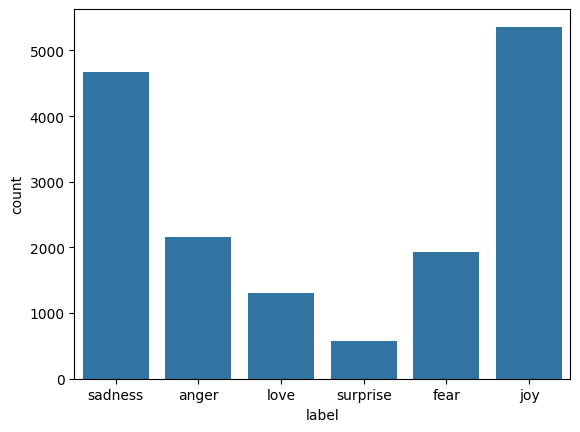

In [38]:
sns.countplot(x="label", data=df_train)

In [39]:
# check in asc ordervice
df_train["label"].value_counts()

label
joy         5362
sadness     4666
anger       2159
fear        1937
love        1304
surprise     572
Name: count, dtype: int64

<Axes: xlabel='label', ylabel='count'>

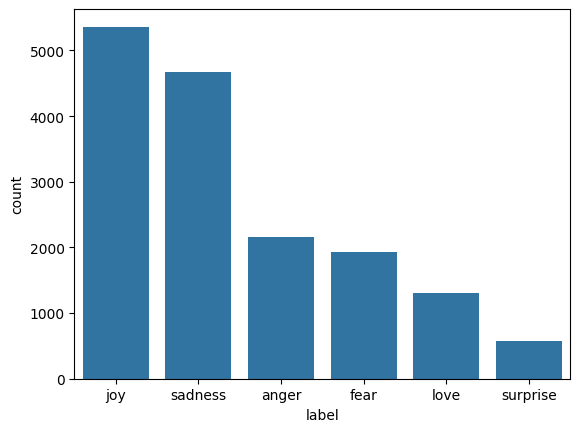

In [40]:
sns.countplot(x="label", data=df_train, order=df_train["label"].value_counts().index)

Data Preprocessing

tokenization, pad sentence, and convert labels to numpy array


In [41]:
df_train

,text,label
0,i didnt feel humiliated,sadness
1,i can go from feeling so hopeless to so damned...,sadness
2,im grabbing a minute to post i feel greedy wrong,anger
3,i am ever feeling nostalgic about the fireplac...,love
4,i am feeling grouchy,anger
...,...,...
15995,i just had a very brief time in the beanbag an...,sadness
15996,i am now turning and i feel pathetic that i am...,sadness
15997,i feel strong and good overall,joy
15998,i feel like this was such a rude comment and i...,anger


# now convert the text and label to numerical values using tokanization


example
nlp = "i feel sad" -> [1,4,40]

nlp = "i feel grouchy" -> [1,4,30]

nlp = "i feel humilated" -> [1,4,90]

so here as we see the output depends on last vector value
unique words are given hiher values


max_words = 10000

# get token

Tokenizer(num_words=max_words,)

but using max words deosnt comes in vocabolary - so its out of vocabolary
so here if the model detect that this word is not in the vocabolary then we can mark it as unkwn then later the word gets some of the vlaue or number weight to it, ( oov_token - < unk >)


we cant we one hot encoding - coulm space inc ( curse of dimentinality )


In [42]:
df_train["text"]

0                                  i didnt feel humiliated
1        i can go from feeling so hopeless to so damned...
2         im grabbing a minute to post i feel greedy wrong
3        i am ever feeling nostalgic about the fireplac...
4                                     i am feeling grouchy
                               ...                        
15995    i just had a very brief time in the beanbag an...
15996    i am now turning and i feel pathetic that i am...
15997                       i feel strong and good overall
15998    i feel like this was such a rude comment and i...
15999    i know a lot but i feel so stupid because i ca...
Name: text, Length: 16000, dtype: object

In [43]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

max_words = 10000


# get token
tokenizer = Tokenizer(num_words=max_words, oov_token="<unk>")
tokenizer.fit_on_texts(df_train["text"])

# eg - "i love nlp" -> ["i":1,"love":5,"nlp":90]
# we provide an id for each word

train_sequence = tokenizer.texts_to_sequences(df_train["text"])
test_sequence = tokenizer.texts_to_sequences(df_test["text"])
# we get only only numbers or tokens -> index
# eg - "i love nlp" -> [1,5,90]

RNN :-

in every timestamp we give input,

x1,x2,x3,x4 -> inputs ( t=1 )

but now 2nd exmaple
we have 12 inputes - x1,x2......x12 ( t=2 )

so here rnn struglle for it, so normalize or fill the rmainng input with 0 for 4 input

so max input 23 then reminng all input become 23 - with 0

# this is called paddding sequence


In [44]:
# padding post - later, pre - at the biggening
# max words ( maxlen ) - 50
# truncating - post , ->

padded_train_seqence = pad_sequences(
    train_sequence, maxlen=50, padding="post", truncating="post"
)
padded_test_seqence = pad_sequences(
    test_sequence, maxlen=50, padding="post", truncating="post"
)

padded_train_seqence

#   [[   2,  139,    3, ...,    0,    0,    0],
#    [   2,   40,  101, ...,    0,    0,    0],
#    [  17, 3060,    7, ...,    0,    0,    0],
#    ...,
#    [   2,    3,  327, ...,    0,    0,    0],
#    [   2,    3,   14, ...,    0,    0,    0],
#    [   2,   47,    7, ...,    0,    0,    0]],

array([[   2,  139,    3, ...,    0,    0,    0],
       [   2,   40,  101, ...,    0,    0,    0],
       [  17, 3060,    7, ...,    0,    0,    0],
       ...,
       [   2,    3,  327, ...,    0,    0,    0],
       [   2,    3,   14, ...,    0,    0,    0],
       [   2,   47,    7, ...,    0,    0,    0]],
      shape=(16000, 50), dtype=int32)

In [45]:
# convert label to number same as text using numpy

train_labels = np.array(train_label)
test_labels = np.array(test_label)

# train_labels
# array([0, 0, 0, ..., 1, 1, 4], shape=(2000,))

num_clases = len(np.unique(train_labels))
# num_clases - 6
print(f"vocabolary size : {len(tokenizer.word_index)}")
print(f"max sequence length : {padded_train_seqence.shape[1]}")

vocabolary size : 15213
max sequence length : 50


# 5 shared Training utilities


example - 13500 total samples

sad - 5000 - weight low -

happy - 4500

joy - 1700

surprise - 800

emo - 900

fear - 600 - weight hight -

weight = total samples / ( num_class \* samples_in_the_class )

used to balance the attention or focus

eg -

wt(sad) = 13500 / ( 6 \* 5000 ) = 0.45

wt(happy) = 13500 / ( 6 \* 4500 ) = 0.50

wt(joy) = 13500 / ( 6 \* 1700 ) = 1.32

wt(surprise) = 13500 / ( 6 \* 800 ) = 2.81

wt(emo) = 13500 / ( 6 \* 900 ) = 2.50

wt(happy) = 13500 / ( 6 \* 600 ) = 3.75


In [46]:
from sklearn.utils import class_weight

class_weights = class_weight.compute_class_weight(
    class_weight="balanced", classes=np.unique(train_labels), y=train_labels
)

class_weights_dic = dict(enumerate(class_weights))
# enumerate give the index to element

print(train_labels)
class_weights_dic

[0 0 3 ... 1 3 0]


{0: np.float64(0.5715102157451064),
 1: np.float64(0.49732686808404825),
 2: np.float64(2.044989775051125),
 3: np.float64(1.2351397251814111),
 4: np.float64(1.3766993632765445),
 5: np.float64(4.662004662004662)}

early stopping - so when on epocs loss reduction is reduced a lot or not changing the loss balue then we stop ( reduce proccesing power )

1 - training - training

2 - test - unseen data

3 - validation - train on few parametrs n check score wch one is best para

there will be 2 looses - loss and validation loss

we monitor if noth the loss are changing


In [47]:
from tensorflow.keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(
    monitor="val_loss", patience=3, restore_best_weights=True
)
# so here we stop epocs when 3 loss has same values and get all the weights n train the model on it

# RNN Architecture

input layer ----> Embedding layer (more information of the words semantic meaning ) [300 vector space ]----> [ RNN Layer -> RNN Layer -> RNN Layer ] ---->


In [48]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Embedding, Dense, Dropout, LSTM, GRU

rnn_model = Sequential(
    [
        Embedding(
            input_dim=max_words, output_dim=128, input_length=50
        ),  # embedding layer
        SimpleRNN(units=128, return_sequences=True),  # rnn layer
        Dropout(0.5),  # 50% of hidden layer is removed to avoid oerfitting
        SimpleRNN(units=64),  # rnn layer
        Dropout(0.5),  # 50% of hidden layer is removed to avoid oerfitting
        Dense(units=num_clases, activation="softmax"),  # ouptut layer
    ]
)

rnn_model.compile(
    optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"]
)

C:\Users\YASHASH RAVI\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\layers\core\embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


1> last rnn output - 1d
2> use return sequence


In [49]:
rnn_model.fit(
    padded_train_seqence,  # input data
    train_labels,  # output data
    validation_data=[padded_test_seqence, test_labels],
    epochs=20,
    batch_size=32,
    class_weight=class_weights_dic,
    callbacks=[early_stopping],
)

rnn_loss, rnn_accuracy = rnn_model.evaluate(padded_test_seqence, test_labels)
print(f"RNN Loss : {rnn_loss}")
print(f"RNN Accuracy  : {rnn_accuracy}")

Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 11s 18ms/step - accuracy: 0.1583 - loss: 1.9037 - val_accuracy: 0.0600 - val_loss: 1.8287
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - accuracy: 0.1679 - loss: 1.8021 - val_accuracy: 0.0730 - val_loss: 1.8107
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 8s 15ms/step - accuracy: 0.1634 - loss: 1.7809 - val_accuracy: 0.1030 - val_loss: 1.7844
Epoch 4/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - accuracy: 0.1486 - loss: 1.7624 - val_accuracy: 0.0855 - val_loss: 1.8138
Epoch 5/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 8s 15ms/step - accuracy: 0.1673 - loss: 1.7467 - val_accuracy: 0.0960 - val_loss: 1.8105
Epoch 6/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 8s 15ms/step - accuracy: 0.1494 - loss: 1.7476 - val_accuracy: 0.1435 - val_loss: 1.7846
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.1030 - loss: 1.7844
RNN Loss : 1.7844384908676147
RNN Accuracy  : 0.10300000011920929


as we see here model is not good as accuracy is not good so move to next mdoel


# Model 2 - training with LSTM


In [50]:
lstm_model = Sequential(
    [
        Embedding(
            input_dim=max_words, output_dim=128, input_length=50
        ),  # embedding layer
        LSTM(units=128, return_sequences=True),  # lstm layer
        Dropout(0.5),  # 50% of hidden layer is removed to avoid oerfitting
        LSTM(units=64),  # lstm layer
        Dropout(0.5),  # 50% of hidden layer is removed to avoid oerfitting
        Dense(units=num_clases, activation="softmax"),  # ouptut layer
    ]
)

lstm_model.compile(
    optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"]
)

In [51]:
lstm_model.fit(
    padded_train_seqence,  # input data
    train_labels,  # output data
    validation_data=[padded_test_seqence, test_labels],
    epochs=20,
    batch_size=32,
    class_weight=class_weights_dic,
    callbacks=[early_stopping],
)

lstm_loss, lstm_accuracy = lstm_model.evaluate(padded_test_seqence, test_labels)
print(f"lstm Loss : {lstm_loss}")
print(f"lstm Accuracy  : {lstm_accuracy}")

Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 36s 69ms/step - accuracy: 0.1503 - loss: 1.7947 - val_accuracy: 0.1115 - val_loss: 1.7968
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 35s 70ms/step - accuracy: 0.1546 - loss: 1.7933 - val_accuracy: 0.1330 - val_loss: 1.7931
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 47s 94ms/step - accuracy: 0.1489 - loss: 1.7924 - val_accuracy: 0.0690 - val_loss: 1.7953
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - accuracy: 0.1115 - loss: 1.7968
lstm Loss : 1.7968446016311646
lstm Accuracy  : 0.11150000244379044


# model 3 - GRU


In [52]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Embedding, Dense, Dropout, LSTM, GRU

gru_model = Sequential(
    [
        Embedding(
            input_dim=max_words, output_dim=128, input_length=50
        ),  # embedding layer
        GRU(units=128, return_sequences=True),  # lstm layer
        Dropout(0.5),  # 50% of hidden layer is removed to avoid oerfitting
        GRU(units=64),  # lstm layer
        Dropout(0.5),  # 50% of hidden layer is removed to avoid oerfitting
        Dense(units=num_clases, activation="softmax"),  # ouptut layer
    ]
)

gru_model.compile(
    optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"]
)

In [53]:
gru_model.fit(
    padded_train_seqence,  # input data
    train_labels,  # output data
    validation_data=[padded_test_seqence, test_labels],
    epochs=20,
    batch_size=32,
    class_weight=class_weights_dic,
    callbacks=[early_stopping],
)

gru_loss, gru_accuracy = gru_model.evaluate(padded_test_seqence, test_labels)
print(f"gru Loss : {gru_loss}")
print(f"gru Accuracy  : {gru_accuracy}")

Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 44s 76ms/step - accuracy: 0.1513 - loss: 1.7958 - val_accuracy: 0.1155 - val_loss: 1.7821
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 42s 77ms/step - accuracy: 0.1529 - loss: 1.7957 - val_accuracy: 0.0350 - val_loss: 1.7943
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 40s 74ms/step - accuracy: 0.1426 - loss: 1.7950 - val_accuracy: 0.0815 - val_loss: 1.7909
Epoch 4/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 40s 72ms/step - accuracy: 0.1464 - loss: 1.7936 - val_accuracy: 0.3445 - val_loss: 1.7741
Epoch 5/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 37s 73ms/step - accuracy: 0.1532 - loss: 1.7912 - val_accuracy: 0.0350 - val_loss: 1.8146
Epoch 6/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 37s 74ms/step - accuracy: 0.1500 - loss: 1.7831 - val_accuracy: 0.1330 - val_loss: 1.7884
Epoch 7/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 38s 75ms/step - accuracy: 0.1719 - loss: 1.7531 - val_accuracy: 0.2730 - val_loss: 1.7921
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.3445 - loss: 1.7741
gru Loss : 1.774

{ lstm - has 4 gates consmes more power }
{ gru - 2 gates, better parameter than lstm }

for now e use gru n build advance model - if accuracy inc

else lstm


# best optimized model


In [54]:
resule_df = pd.DataFrame(
    {
        "Model": ["RNN", "LSTM", "GRU"],
        "Test Loss": [rnn_loss, lstm_loss, gru_loss],
        "Test Accuracy": [rnn_accuracy, lstm_accuracy, gru_accuracy],
    }
).sort_values(by="Test Accuracy", ascending=False)

resule_df

,Model,Test Loss,Test Accuracy
2,GRU,1.774120,0.3445
1,LSTM,1.796845,0.1115
0,RNN,1.784438,0.1030


# best optimized model - GRU

bidirectional GRU - model reads from both direction simultanously

2 pases [ L ----> R then R ----> L ]


In [55]:
from tensorflow.keras.layers import Bidirectional

BiGRU = Sequential(
    [
        Embedding(
            input_dim=max_words, output_dim=128, input_length=50
        ),  # embedding layer
        Bidirectional(GRU(128, return_sequences=True)),
        Dropout(0.5),
        Bidirectional(GRU(64)),
        Dropout(0.5),
        Dense(num_clases, activation="softmax"),  # output layer
    ]
)

BiGRU.compile(
    optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"]
)

BiGRU.summary()

C:\Users\YASHASH RAVI\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\layers\core\embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_5 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_2 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_3 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [56]:
BiGRU.fit(
    padded_train_seqence,  # input data
    train_labels,  # output data
    validation_data=[padded_test_seqence, test_labels],
    epochs=20,
    batch_size=32,
    class_weight=class_weights_dic,
    callbacks=[early_stopping],
)

BiGRU_loss, BiGRU_accuracy = BiGRU.evaluate(padded_test_seqence, test_labels)
print(f"BiGRU Loss : {BiGRU_loss}")
print(f"BiGRU Accuracy  : {BiGRU_accuracy}")

Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 68s 121ms/step - accuracy: 0.4897 - loss: 1.1826 - val_accuracy: 0.8635 - val_loss: 0.4745
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 81s 120ms/step - accuracy: 0.9053 - loss: 0.2834 - val_accuracy: 0.9040 - val_loss: 0.2856
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 60s 120ms/step - accuracy: 0.9394 - loss: 0.1623 - val_accuracy: 0.9210 - val_loss: 0.2136
Epoch 4/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 61s 122ms/step - accuracy: 0.9531 - loss: 0.1254 - val_accuracy: 0.9200 - val_loss: 0.2099
Epoch 5/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 61s 123ms/step - accuracy: 0.9665 - loss: 0.0923 - val_accuracy: 0.9140 - val_loss: 0.2640
Epoch 6/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 81s 120ms/step - accuracy: 0.9719 - loss: 0.0767 - val_accuracy: 0.9140 - val_loss: 0.2872
Epoch 7/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 82s 120ms/step - accuracy: 0.9793 - loss: 0.0600 - val_accuracy: 0.9155 - val_loss: 0.2789
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - accuracy: 0.9200 - loss: 0.2099
BiGRU Los

create confusion matrix


In [57]:
from sklearn.metrics import confusion_matrix

# BiGRU_predictions = BiGRU.predict(padded_test_seqence)
# BiGRU_predictions
# now want only the max output among the array given  - [9.9732482e-01, 3.5080613e-04, 2.2280727e-04, 2.0227632e-03,
# 6.3122337e-05, 1.5694362e-05] so here max is 9.97 ( sad )

BiGRU_predictions = np.argmax(BiGRU.predict(padded_test_seqence), axis=1)
BiGRU_predictions

63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 46ms/step


array([0, 0, 0, ..., 1, 1, 4], shape=(2000,))

<Axes: >

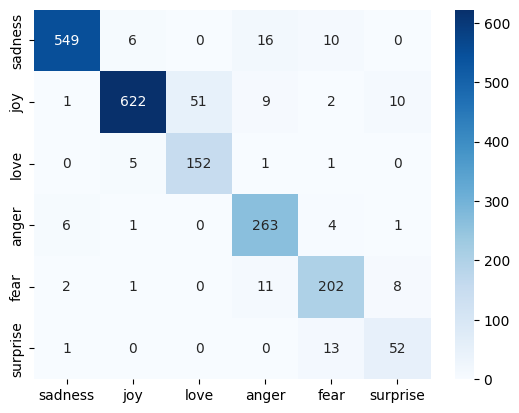

In [58]:
# sns.heatmap(confusion_matrix(test_label,BiGRU_predictions),annot=True,fmt='d',cmap="Blues")
sns.heatmap(
    confusion_matrix(test_label, BiGRU_predictions),
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_name,
    yticklabels=label_name,
)

# Model Prediction 

In [5]:
import pickle
from keras.models import load_model
import numpy as np

model = load_model(r"Artifacts\BiGRU_Model.keras")
tokenizer = None

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences


with open(r"Artifacts\tokenizer.pkl", "rb") as file:
       tokenizer = pickle.load(file)  # tokenizer model
# eg - "i love nlp" -> [1,5,90]

In [12]:
sample_texts = [
    "I am feeling incredibly happy today because everything went perfectly!",
    "I feel so sad and lonely after hearing the bad news.",
    "I am extremely angry because they completely ignored my request.",
    "I was terrified when I heard a strange noise outside my house.",
    "I am really surprised by the wonderful gift my friend gave me!",
    "I feel so joyful because I finally achieved my dream.",
    "I am worried and scared about what might happen tomorrow.",
    "I am extremely excited because I am going on a trip with my friends!",
    "I feel disappointed because the event did not go as I expected.",
    "I was shocked when I suddenly received the unexpected news!"
]
# sample_texts = ["i am feeling incredibly happy today because everything went perfectly"]


sample_sequence = tokenizer.texts_to_sequences(sample_texts)
sample_padded_sequences = pad_sequences(sample_sequence,maxlen=50,padding='post',truncating='post')

sample_pred = np.argmax(model.predict(sample_padded_sequences),axis=1)
sample_pred

label_name = ['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']

for i in range(len(sample_texts)):
    print(f'text : {sample_texts[i]}\nPredicted emotion : {label_name[sample_pred[i]]}')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
text : I am feeling incredibly happy today because everything went perfectly!
Predicted emotion : joy
text : I feel so sad and lonely after hearing the bad news.
Predicted emotion : sadness
text : I am extremely angry because they completely ignored my request.
Predicted emotion : anger
text : I was terrified when I heard a strange noise outside my house.
Predicted emotion : fear
text : I am really surprised by the wonderful gift my friend gave me!
Predicted emotion : surprise
text : I feel so joyful because I finally achieved my dream.
Predicted emotion : joy
text : I am worried and scared about what might happen tomorrow.
Predicted emotion : fear
text : I am extremely excited because I am going on a trip with my friends!
Predicted emotion : anger
text : I feel disappointed because the event did not go as I expected.
Predicted emotion : sadness
text : I was shocked when I suddenly received the unexpected news!
Predicted emotion : surprise


# saving the model

In [60]:
import os
import pickle

model_dir = 'Artifacts'
os.makedirs(model_dir, exist_ok=True) # all working and exported fiels will be stored

# save our model BiGRU model
BiGRU.save(os.path.join(model_dir,'BiGRU_Model.keras'))

# save the tokenizer model
with open(os.path.join(model_dir,'tokenizer.pkl'),'wb') as file:
    pickle.dump(tokenizer,file)

